### chatbot with MCP Server

In [1]:
%%pip install langchain-mcp-adapters mcp pywin32 -Uqqq

UsageError: Cell magic `%%pip` not found (But line magic `%pip` exists, did you mean that instead?).


### MCP Server 연동
- http 원격지의 MCP Server를 web방식 호출
-stdio MCP Client system에서 MCP Server 구동하는 경우

In [2]:
# MultiServerMCPClient로 MCP서버 2개 연결 후 도구 목록 조회
from langchain_mcp_adapters.client import MultiServerMCPClient
import os

CONTEXT7_API_KEY = os.getenv('CONTEXT7_API_KEY')

mcp_client = MultiServerMCPClient({
    "docs-langchain": {
        "url": "https://docs.langchain.com/mcp",
        "transport": 'http'
    },
    "context7": {
        "url": "https://mcp.context7.com/mcp",
        "headers": {
            "CONTEXT7_API_KEY": CONTEXT7_API_KEY
        },
        "transport": "http"
    }
})

mcp_tools = await mcp_client.get_tools()
mcp_tools 

[StructuredTool(name='search_docs_by_lang_chain', description='Search across the Docs by LangChain knowledge base to find relevant information, code examples, API references, and guides. Use this tool when you need to answer questions about Docs by LangChain, find specific documentation, understand how features work, or locate implementation details. The search returns contextual content with titles and direct links to the documentation pages. If you need the full content of a specific page, use the query_docs_filesystem tool to `head` or `cat` the page path (append `.mdx` to the path returned from search — e.g. `head -200 /api-reference/create-customer.mdx`).', args_schema={'type': 'object', 'properties': {'query': {'type': 'string', 'description': 'Search query'}}, 'required': ['query'], 'additionalProperties': False}, metadata={'title': None, 'readOnlyHint': True, 'destructiveHint': False, 'idempotentHint': True, 'openWorldHint': False}, handle_tool_error=<function _handle_mcp_tool_

In [3]:
from typing import TypedDict, Annotated, List     # 타입 힌트 도구
from langgraph.graph.message import add_messages  # 메시지 누적 처리를 해줄 헬퍼
from langchain.chat_models import init_chat_model 
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage # 메시지 타입
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results = 3)

# 그래프에서 사용할 상태(TypedDict) 스키마 
class State(TypedDict):
    messages: Annotated[List, add_messages] # messages 필드가 add_messages 규칙으로 누적 저장

llm = init_chat_model('gpt-5.6-luna')
tools = [tavily_tool]
llm_with_tools = llm.bind_tools(tools) # llm에 도구 스펙 파인딩



# State의 messages를 입력으로 받아, 응답 메시지를 추가해주는 노드 함수
def chatbot(state: State):   # ← 타입 힌트는 대문자 State
    response = llm.invoke(state['messages']) # 누적된 메시지 리스트로 LLM 호출
    return {'messages': [response]}          # add_messages 규칙에 의해 기존 messages에 응답이 누적됨


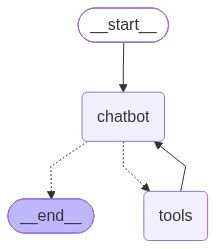

In [5]:
# langgraph.prebuilt 모듈의 ToolNode, tools_condition 함수 사용한 워크플로우
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

builder = StateGraph(State) # state 스키마 기반 그래프 설계 객체 생성 
tool_node = ToolNode(tools)

builder.add_edge(START, 'chatbot')  # 시작 노드 -> chatbot 노드

builder.add_node('chatbot', chatbot) # chatbot 노드
builder.add_node('tools', tool_node) # tools 노드

builder.add_conditional_edges('chatbot', tools_condition)
builder.add_edge('tools', 'chatbot')

graph = builder.compile() # 설계된 워크플로우를 실행 가능한 그래프로 컴파일
 
graph

In [6]:
from pprint import pprint

user_query = '최근 삼성전자와 하이닉스주가는 어떻게 돼? MCP langchain 사용해줘  '

state = {'messages': [('human', user_query)]}

response = graph.invoke(state) # 그래프 비동기 실행
pprint(response)
print(response)
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='최근 삼성전자와 하이닉스주가는 어떻게 돼?', additional_kwargs={}, response_metadata={}, id='322c9604-88e5-478b-ba21-241614a967d7'),
              AIMessage(content='현재 저는 실시간 국내 주가를 직접 조회할 수 없어 **삼성전자(005930)**와 **SK하이닉스(000660)**의 오늘 가격·등락률을 정확히 말씀드리기 어렵습니다.\n\n확인은 다음에서 가능합니다.\n\n- 네이버증권: `삼성전자`, `SK하이닉스`\n- 한국거래소(KRX)\n- 증권사 앱\n\n두 종목은 최근에도 대체로 **메모리 반도체 가격, HBM 수요와 엔비디아 등 AI 반도체 투자, 원·달러 환율, 외국인 수급**에 크게 움직입니다.  \n현재 시세나 기준 날짜를 알려주시면 **최근 흐름, 상승·하락 원인, 두 종목 비교**까지 정리해 드리겠습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 314, 'prompt_tokens': 20, 'total_tokens': 334, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 130, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.6-luna', '